# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [10]:
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric
R = 1.
r = 0.2


lc = 0.03
Lc = 2.
eps_r = 16.

material = Dielectric(relative_permittivity=eps_r)


mesh = AnularDomain(R=R, r=r, scatterer_material = material, verbosity=0, Lc=Lc, lc=lc)


In [11]:
from trefftz.dg.parameters import Elementwise
import numpy as np 

Regions = mesh.regions

refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1.,
                                      Regions.OMEGA: np.sqrt(material.eps_r)})


In [12]:
mesh.n_triangles

648

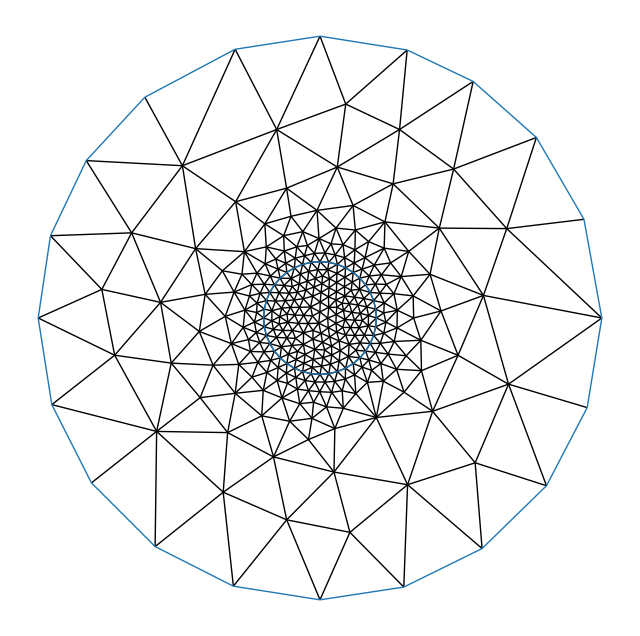

In [13]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

Text(0.5, 1.0, '$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

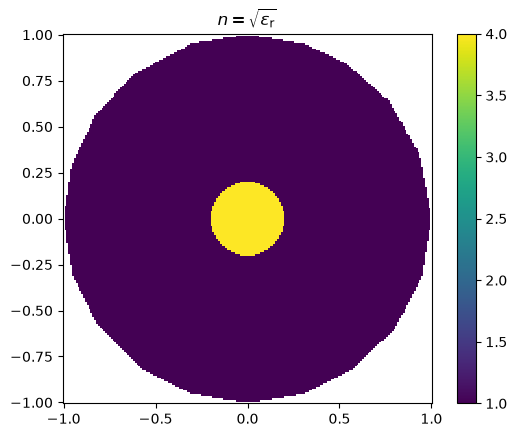

In [14]:
import matplotlib.pyplot as plt
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = refractive_index(X, Y)

plt.pcolormesh(X, Y, Z)
plt.axis('square')
plt.colorbar()
plt.title('$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

In [15]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [16]:
mesh.curve_boundaries([Boundaries.SIGMA, Boundaries.D_OMEGA], radius=[R, r])


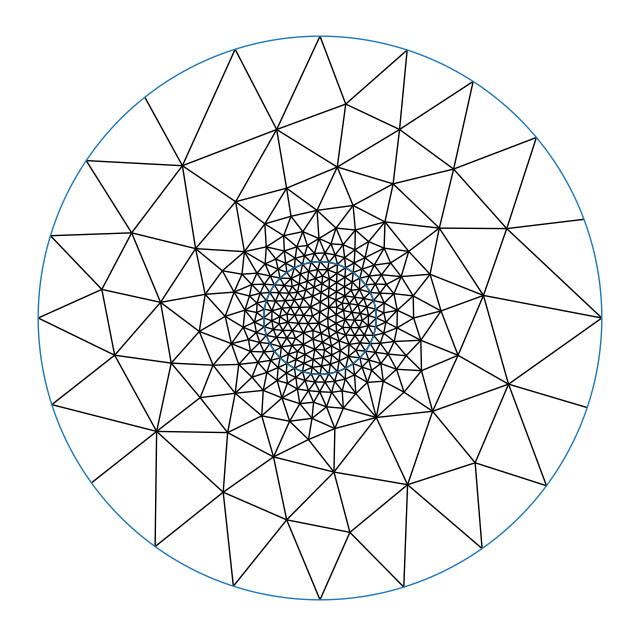

In [17]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [18]:
mesh.curved_boundaries

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [19]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [20]:
import numpy as np
from trefftz.dg.exact import PlaneWave
theta_inc = np.pi
d_inc = np.array([np.cos(theta_inc), np.sin(theta_inc)])
data = PlaneWave(d=d_inc, A=1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [21]:
from trefftz.dg.block_fluxes import UltraWeakFlux

as well as specific ones (for a circular NtD map):

In [22]:
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [23]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [24]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 12
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [25]:
basis.N_DOF

7776

In [26]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [27]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

In [28]:
assembler._regions_local_kernel

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [29]:
from trefftz.problem import Problem
from cases.open_space.exact import nf_diel_cylinder_plane_wave

def u_tot(x, y):
    u_s = nf_diel_cylinder_plane_wave(x, y, k, theta_inc=theta_inc, n=np.sqrt(eps_r), c=np.array([0., 0.]), R=r)
    u_i = np.exp(1j*k*(d_inc[0]*x + d_inc[1]*y))
    RHO = np.sqrt(x**2 + y**2)
    return np.where(RHO<r, u_s, u_s+u_i)


P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True, u=lambda x, y: u_tot(x,y))

In [30]:
P.assemble_LHS()

assembling local operators
region: Sigma


Interior: 100%|██████████| 962/962 [00:00<00:00, 1326.95edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 20/20 [02:22<00:00,  7.14s/edge]


<COOrdinate sparse array of dtype 'complex128'
	with 614592 stored elements and shape (7776, 7776)>

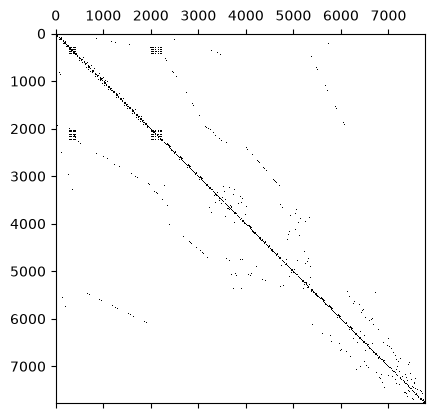

In [31]:
import matplotlib.pyplot as plt 
plt.spy(P.A.toarray())

In [32]:
P.assemble_RHS()

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j], shape=(7776,))

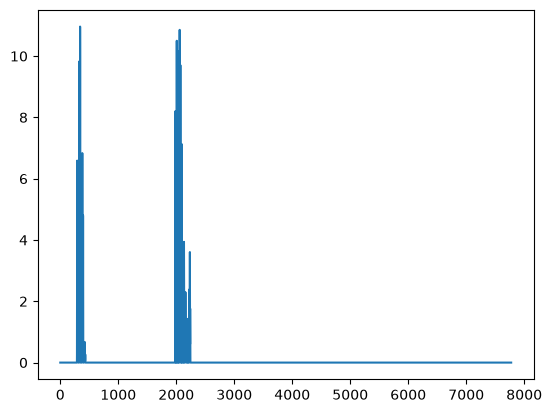

In [33]:
import numpy as np 
plt.plot(np.abs(P.b))

In [34]:
P.solve()

In [35]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 3.97252178e+04+6.31530222e+04j,  1.90193420e+04-7.19789728e+04j,
        -5.80560706e+04+4.73300551e+04j, ...,
        -6.78588515e+04+3.71225547e+04j,  7.20575430e+04-2.51674951e+04j,
        -7.35519347e+04-1.62072930e+04j],
       [ 3.59101144e+00-9.55463006e+00j,  2.54021723e+00-9.75262295e+00j,
        -5.22930104e+00-7.95020027e+00j, ...,
        -7.57816211e+00+5.15545905e+00j,  9.80414331e+00+4.99644198e-01j,
         5.40800793e+00-8.53223403e+00j],
       [-3.58216869e+04+5.03371037e+04j,  5.92162260e+04-8.64873496e+03j,
        -5.37802097e+04-2.37662538e+04j, ...,
        -6.14196095e+04-2.81080821e+04j,  5.03230174e+04+4.29920485e+04j,
        -1.39513626e+04-6.25538503e+04j],
       ...,
       [-2.73275056e-01+4.07963682e-02j, -6.36668239e-02+2.07851910e-02j,
         4.34023102e-02-1.50466671e-02j, ...,
        -1.70588082e-02-5.70719757e-02j,  4.32044115e-02-1.52317624e-02j,
        -6.35623786e-02+2.08968971e-02j],
       [-2.75476167e-01+4.12126941e-02j, -6.

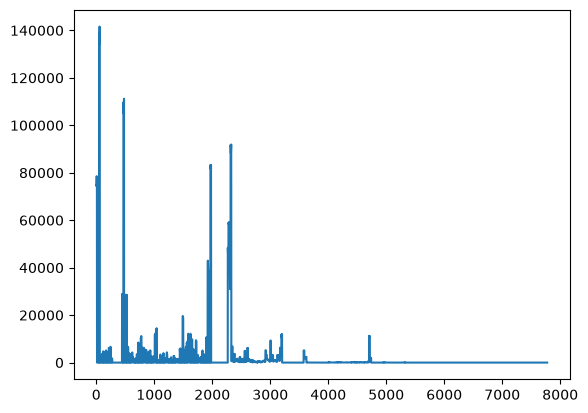

In [36]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

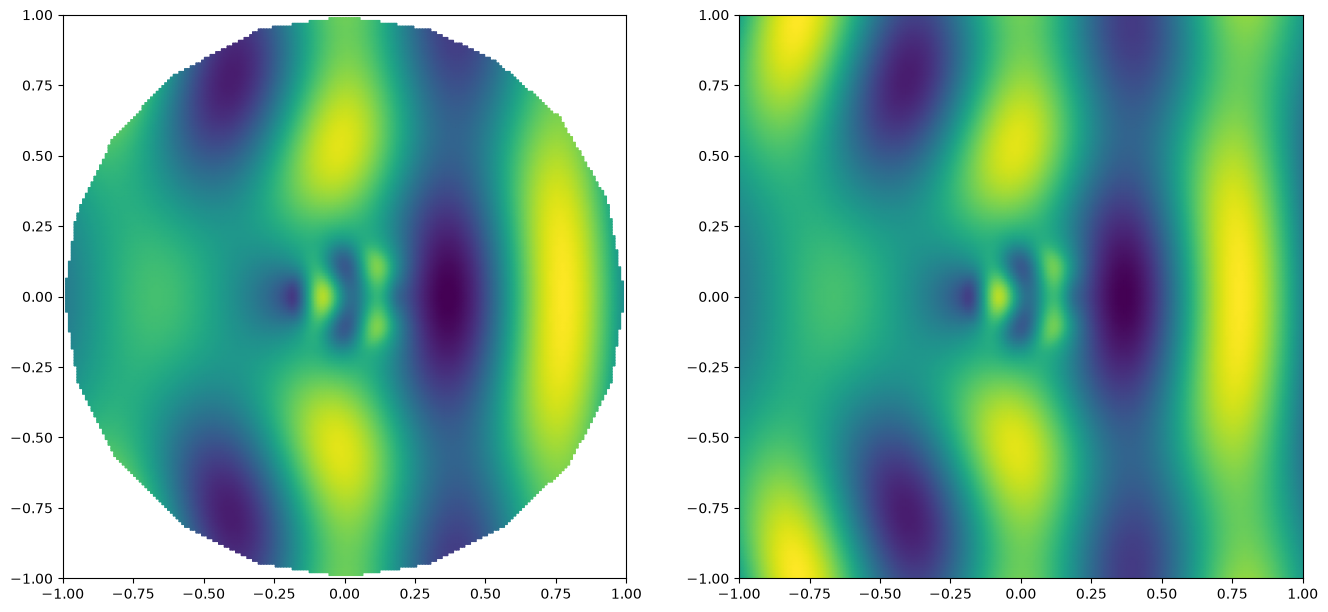

In [40]:
import matplotlib.pyplot as plt
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)
U = P.u(X, Y)

fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmax = np.max(np.real(U))
vmin = np.min(np.real(U))

ax[0].pcolormesh(X, Y, np.real(U_h), vmin=vmin, vmax=vmax, shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(U), vmin=vmin, vmax=vmax, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

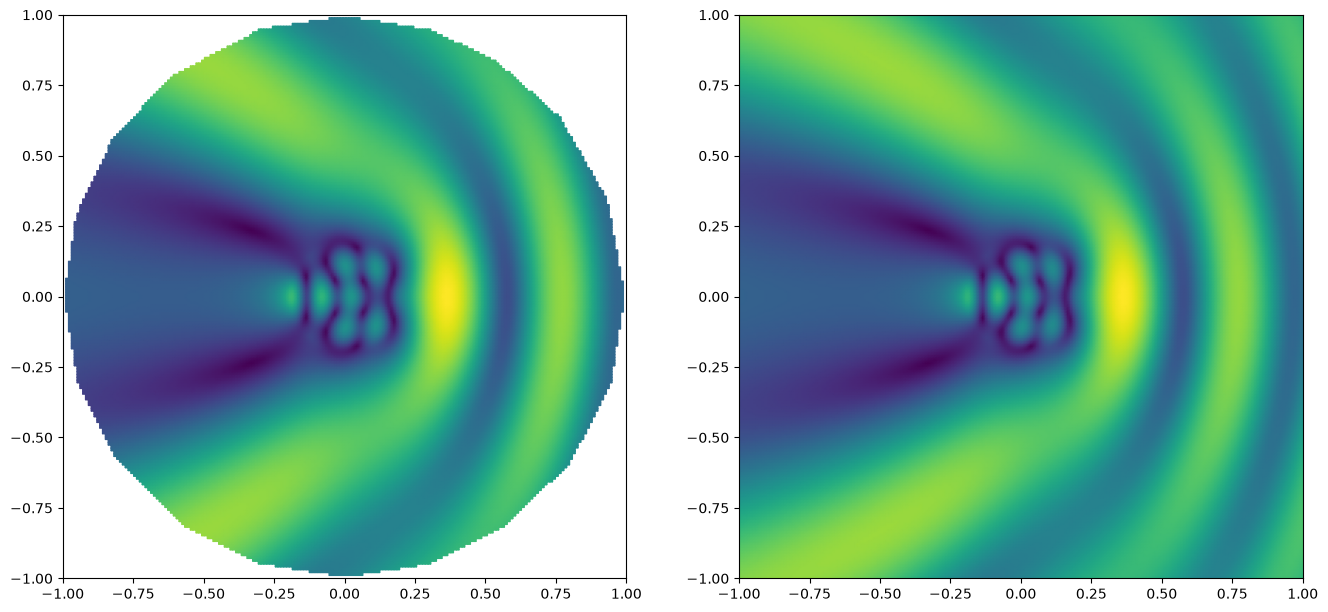

In [41]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.abs(U), shading="gouraud")
ax[1].axis('square')


1.7970874700301992e-05
1.86844992776947e-05
1.773497228317719e-05
1.4805399955735846e-05
1.0202987225337113e-05
1.1257626478400112e-05
1.9157243682604504e-05
1.4859079220389701e-05
1.5208642143071919e-05
1.5292029332250342e-05
8.901944091124022e-06
1.0129815897645907e-05
2.0058531550721323e-05
1.7147880603048404e-05
1.9177588908046805e-05
1.805133530112047e-05
1.1739551052621001e-05
1.187113936934467e-05
1.3959297233398496e-05
1.5105304875112852e-05
1.781909732086585e-05
1.5681000788143044e-05
8.604348820579442e-06
1.040704326511278e-05
5.024177854785575e-07
6.474288022051733e-07
6.117111661999478e-07
1.5129775504020269e-06
1.3102656348517023e-06
3.3638413955678714e-06
2.2515166667894183e-06
5.336057386872894e-07
7.467709269042859e-07
7.321715682101474e-07
6.620516498954373e-07
7.846632513116402e-07
8.492885266884421e-07
9.65705491912651e-06
1.0063955301240148e-05
9.984015883431558e-06
1.1372756881503282e-05
4.6604736520729507e-08
4.45960467065356e-08
2.4206578864212045e-07
3.671287670

Text(0.5, 1.0, '$L^\\infty$ error: nan \n$L^2$ error: 3.50e-02')

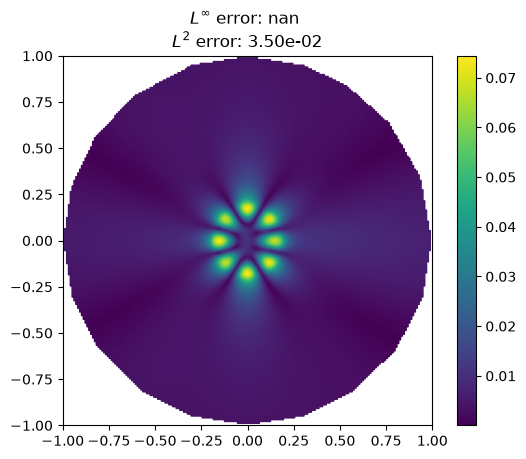

In [42]:
plt.pcolormesh(X, Y, np.abs(U_h - U), shading="gouraud")
plt.axis("square")
plt.colorbar()
plt.title(f'$L^\\infty$ error: {np.max(np.abs(U_h - U))} \n$L^2$ error: {P.compute_error():.2e}')